In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# read the data into a pandas dataframe
banned_books = pd.read_csv("../data/raw/PEN_Combined_21-25_Final.csv")
# Removed msc 'Nation' from state column. It refers to a government department, but is uneeded for our purposes
banned_books = banned_books[banned_books['State'] != 'Nation']

In [26]:
# Regional clusters dictionary (US Census Bureau divisions)
regional_clusters = {
    # Northeast
    'Maine': 'Northeast',
    'New Hampshire': 'Northeast',
    'Vermont': 'Northeast',
    'Massachusetts': 'Northeast',
    'Rhode Island': 'Northeast',
    'Connecticut': 'Northeast',
    'New York': 'Northeast',
    'New Jersey': 'Northeast',
    'Pennsylvania': 'Northeast',
    
    # South
    'Delaware': 'South',
    'Maryland': 'South',
    'Virginia': 'South',
    'West Virginia': 'South',
    'Kentucky': 'South',
    'Tennessee': 'South',
    'North Carolina': 'South',
    'South Carolina': 'South',
    'Georgia': 'South',
    'Florida': 'South',
    'Alabama': 'South',
    'Mississippi': 'South',
    'Arkansas': 'South',
    'Louisiana': 'South',
    'Oklahoma': 'South',
    'Texas': 'South',
    
    # Midwest
    'Ohio': 'Midwest',
    'Indiana': 'Midwest',
    'Illinois': 'Midwest',
    'Michigan': 'Midwest',
    'Wisconsin': 'Midwest',
    'Minnesota': 'Midwest',
    'Iowa': 'Midwest',
    'Missouri': 'Midwest',
    'North Dakota': 'Midwest',
    'South Dakota': 'Midwest',
    'Nebraska': 'Midwest',
    'Kansas': 'Midwest',
    
    # West
    'Montana': 'West',
    'Idaho': 'West',
    'Wyoming': 'West',
    'Colorado': 'West',
    'New Mexico': 'West',
    'Arizona': 'West',
    'Utah': 'West',
    'Nevada': 'West',
    'Washington': 'West',
    'Oregon': 'West',
    'California': 'West',
    'Alaska': 'West',
    'Hawaii': 'West'
}

# Display the dictionary
print("Regional Clusters Dictionary:")
print(f"Total states: {len(regional_clusters)}")
print("\nSample entries:")
for state, region in list(regional_clusters.items())[:10]:
    print(f"  {state}: {region}")

Regional Clusters Dictionary:
Total states: 50

Sample entries:
  Maine: Northeast
  New Hampshire: Northeast
  Vermont: Northeast
  Massachusetts: Northeast
  Rhode Island: Northeast
  Connecticut: Northeast
  New York: Northeast
  New Jersey: Northeast
  Pennsylvania: Northeast
  Delaware: South


# Questions

### How many books are banned per state?

In [27]:
books_per_state = banned_books['State'].value_counts().sort_values(ascending=False)

print("Number of books banned per state: ")
print(books_per_state)

Number of books banned per state: 
State
Florida           8837
Iowa              3798
Texas             3744
Tennessee         2016
Pennsylvania       737
Wisconsin          482
Missouri           419
Utah               351
Virginia           312
South Carolina     197
Georgia            153
North Carolina     137
Kentucky           103
Maine               97
Michigan            80
Maryland            71
Wyoming             65
Idaho               63
Oregon              61
Alaska              57
Oklahoma            45
Kansas              38
Colorado            27
North Dakota        27
New York            25
Indiana             24
Mississippi         22
Minnesota           19
Illinois             7
South Dakota         7
New Jersey           7
Ohio                 7
Nebraska             6
Arkansas             5
Washington           5
California           3
Montana              3
New Hampshire        2
West Virginia        2
Massachusetts        2
Arizona              2
Rhode Island    

### Which states have the most bans?

In [28]:
print(books_per_state.idxmax())

Florida


### Are there regional clusters (South, Midwest, etc.)?

In [29]:
state_region_df = pd.DataFrame({'State': books_per_state.index, 'Bans':books_per_state.values})
state_region_df['Region'] = state_region_df['State'].map(regional_clusters)


regional_stats = state_region_df.groupby('Region').agg({'Bans':['sum', 'mean', 'count']})
regional_stats

Bans              
             sum    mean count
Region                        
Midwest     4914   409.5    12
Northeast    872   109.0     8
South      15645  1117.5    14
West         637    63.7    10

### What's the time trend by state?

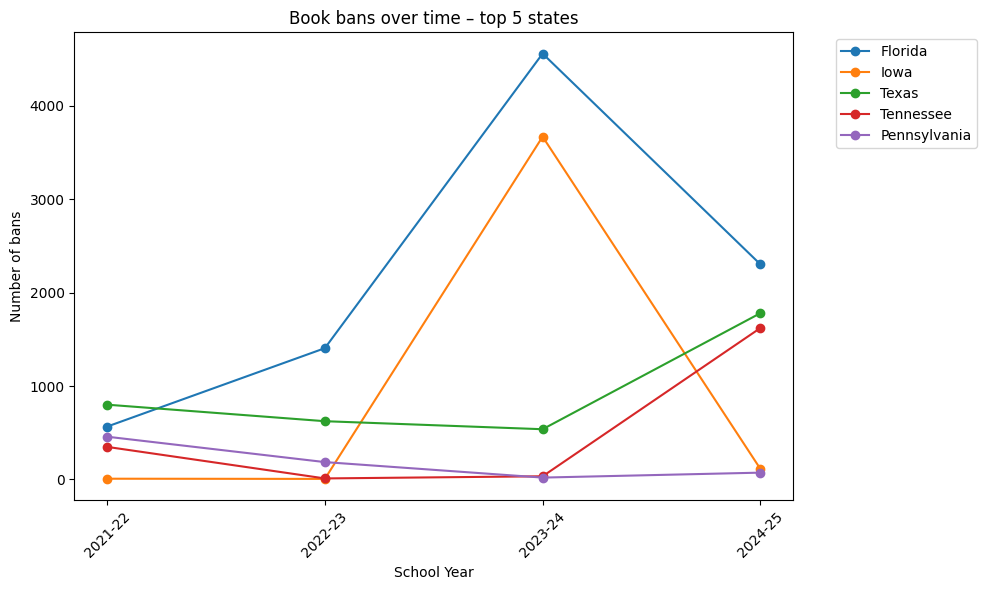

In [30]:
# Time trend for all states

# (1) Create a School Year x State table of bans
trend_pivot = (bans_by_state_year.pivot(index='School Year', columns='State', values='num_bans').fillna(0).sort_index())
trend_pivot  # each row is a school year, each column is a state

# (2) Plot time trends for the top N states by total bans
top_n = 5  # change this number if you want more or fewer states

top_states = (bans_by_state_year.groupby('State')['num_bans'].sum().sort_values(ascending=False).head(top_n).index)

plt.figure(figsize=(10, 6))
for s in top_states:
    s_trend = (bans_by_state_year[bans_by_state_year['State'] == s].sort_values('School Year'))
    plt.plot(s_trend['School Year'], s_trend['num_bans'], marker='o', label=s)

plt.title(f'Book bans over time – top {top_n} states')
plt.xlabel('School Year')
plt.ylabel('Number of bans')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Any states with zero bans?

In [31]:
state_region_df[state_region_df['Bans'] == 0]

,State,Bans,Region


In [32]:
print("There are no states with no book bans.")

There are no states with no book bans.
